In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt 

### Step 1: Sanity check of the training for neural nets

We will first fetch some data from our dataset and use the `encoder_features` and `encoder_labels` net to check if the encoded image of a ring and the encoded labels are close in latent space (we can visualize it in 2d). 

In [2]:
from astro_peek import Encoder

def load_model(paths):
    model_list = []
    for path in tqdm(paths): 
        model_data = torch.load(path, map_location = "cpu")
        cfg = model_data['model_cfg']
        model = Encoder(cfg)
        model_list.append(model)
    return model_list

ModuleNotFoundError: No module named 'astro_peek'

In [21]:
from glob import glob
from tqdm import tqdm 
from natsort import natsorted

model_path = "/home/noedia/links/scratch/crl/experiments/rings/models/"
encoders_features_dir = "encoder_features/"
encoders_labels_dir = "encoder_labels/"
pattern = "*.pt"

encoder_x_paths = natsorted(glob(model_path + encoders_features_dir + pattern))  
encoder_y_paths = natsorted(glob(model_path + encoders_labels_dir + pattern))

print("Loading the models for different random seeds ")
encoder_x_list = load_model(encoder_x_paths)
encoder_y_list = load_model(encoder_y_paths)

Loading the models for different random seeds 


100%|██████████| 11/11 [00:00<00:00, 252.27it/s]


Let's get some rings

In [22]:
from datasets import load_from_disk

ring_dset_dir = "/home/noedia/links/scratch/crl/experiments/rings/data" 
ring_dset = load_from_disk(ring_dset_dir)
ring_data = ring_dset["train"][:50]

x = ring_data['image']
y = ring_data['theta']

Checking a few rings 

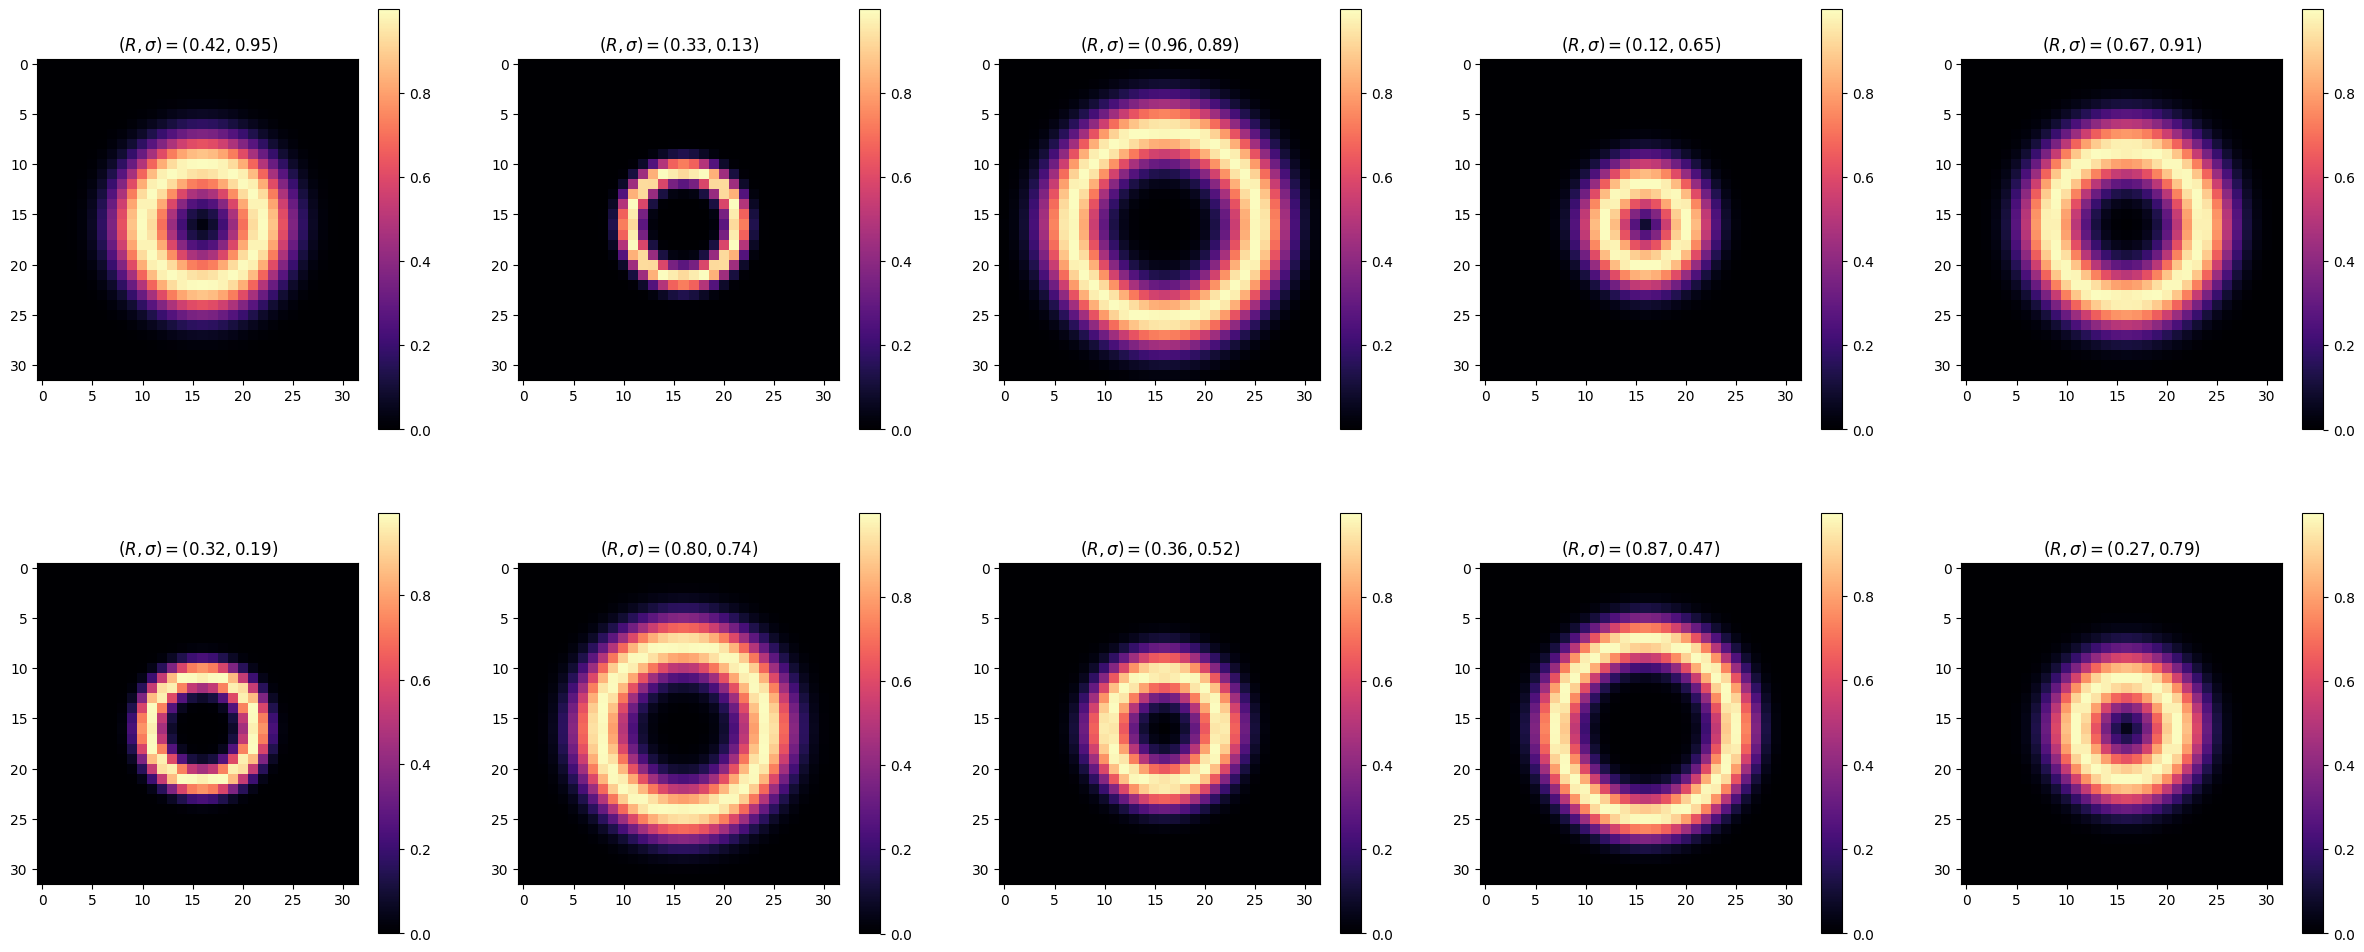

In [26]:
fig, axs = plt.subplots(2, 5, figsize = (6 * 5, 6 * 2))

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(x[i], cmap = "magma")
    label = y[i]
    plt.colorbar(im)
    ax.set(title = r"$(R, \sigma) = (%.2f, %.2f)$"%(label[0], label[1]))

In [27]:
encoder_x = encoder_x_list[0]
encoder_y = encoder_y_list[0]

zx = encoder_x(torch.tensor(x)).detach()
zy = encoder_y(torch.tensor(y)).detach()

In [30]:
with torch.no_grad():
    sims = zx @ zy.T
    preds = sims.argmax(dim=1)
    acc = (preds == torch.arange(len(preds))).float().mean()

In [34]:
sims.shape

torch.Size([50, 50])

So they don't look quite the same... More importantly, the `encoder_labels` seems to map extremely closely in latent space ring parameters that are very different...

It might be a normalization issue, let's try to retrain with a log normalization applied to $\sigma$. And maybe to the radius as well ? 

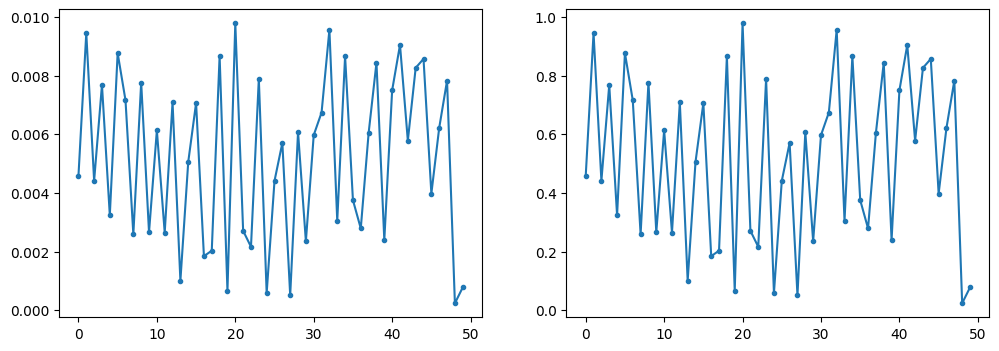

In [89]:
y = np.array(y)

fig, axs = plt.subplots(1, 2, figsize = (6 * 2, 4))

ax = axs[0]
ax.plot(y[:, 1], marker = ".")


ax = axs[1]
ax.plot(100 * y[:, 1], marker = ".")

## CCA and MCCA
Let's try what Salma did for a single pair of `encoder_features` for now. 

In [ ]:
def plot_CCA_all_latents(dims, scores, models):
    i, j = models[0], models[1]
    plt.figure(figsize=(13,4))
    plt.plot(dims, scores, "o", label="CCA")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA value")
    plt.title("CCA value vs latent dimenion for models "+str(i)+" and "+str(j))
    plt.xticks(dims)
    plt.ylim(0,1)
    plt.show()
    
def plot_features(z, latent, models):
    latent_label = latent+1
    i, j = models[0], models[1]
    z1, z2 = z[i-1], z[j-1]
    
    # Plot the view in the shared latent space for the desired latent 
    plt.figure(figsize=(6,3))
    plt.title('Correlation between models '+str(i)+' and '+str(j)+' in shared latent space for latent '+str(latent_label))
    plt.scatter(z1[:,latent], z2[:,latent], marker='.')
    plt.xlabel('Feature '+str(latent_label)+' for model '+str(i))
    plt.ylabel('Feature '+str(latent_label)+' for model '+str(j))
    plt.show()

In [ ]:
encoder_a = encoder_x_list[0]
encoder_b = encoder_x_list[1]

ndims = 50
data = JointData(
    n_views=2,
    n_samples=300,
    n_features=[50, 50],
    latent_dimensions=ndims,
    signal_to_noise=2.0,
    random_state=0,
)
train_views = data.sample() # shape (n_views, n_samples, ndims)
test_views  = data.sample() # shape (n_views, n_samples, ndims)

dims = np.arange(1,ndims+1)

# Fit the CCA
model = CCA(latent_dimensions=ndims).fit(train_views) 

# Canonical correlations on the test data, one value per latent dimension 
corrs = model.score(test_views) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))



## $R^2$ score

In [17]:


encoder_x_list = []

model_list = []
print("Loading the models for different random seeds ")
for path in tqdm(encoder_x_paths): 
    model_data = torch.load(path, map_location = "cpu")

In [18]:
model_data.keys()

dict_keys(['model', 'model_cfg', 'seed'])

['/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_47_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_38_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_40_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_42_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_45_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_43_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_44_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_37_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_46_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_39_latentdim_2.pt',


In [12]:
model_path + encoders_features_dir + pattern

'/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/*.pt'